In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
data = {
    "text": [
        "I feel very sad and alone",
        "I am happy today",
        "I am feeling anxious about exams",
        "Life is normal and good",
        "I can't sleep and feel depressed"
    ],
    "label": [
        "depression",
        "normal",
        "anxiety",
        "normal",
        "depression"
    ]
}

import pandas as pd
df = pd.DataFrame(data)

df.head()

,text,label
0,I feel very sad and alone,depression
1,I am happy today,normal
2,I am feeling anxious about exams,anxiety
3,Life is normal and good,normal
4,I can't sleep and feel depressed,depression


In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# download once
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    tokens = word_tokenize(text)  # split words
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return " ".join(tokens)

# apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,label,clean_text
0,I feel very sad and alone,depression,feel sad alone
1,I am happy today,normal,happy today
2,I am feeling anxious about exams,anxiety,feeling anxious exams
3,Life is normal and good,normal,life normal good
4,I can't sleep and feel depressed,depression,ca n't sleep feel depressed


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)

X = vectorizer.fit_transform(df['clean_text'])

y = df['label']

print("Shape of X:", X.shape)

Shape of X: (5, 14)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4, 14)
Testing data: (1, 14)


In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     anxiety       0.00      0.00      0.00       1.0
      normal       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
df = df.rename(columns={
    "review": "text",
    "sentiment": "label"
})

In [ ]:
df['label'].value_counts()

,count
label,
positive,25000
negative,25000


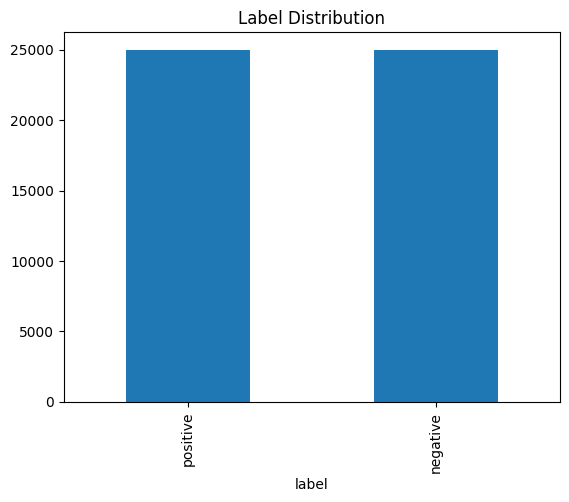

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.show()